In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import datetime
from utils import get_target
import collections

p = Path("data/futures")
parquet_files = sorted(p.glob("*.parquet"))
parquet_files

# %%
dfs = []
for f in parquet_files:
    df = pd.read_parquet(f)

    # flatten multi index
    df.columns = [c[0] for c in df.columns]

    df["ticker"] = f.stem

    df["timestamp"] = pd.to_datetime(df["timestamp"])

    dfs.append(df)

df = pd.concat(dfs, ignore_index=True, sort=False)
# df = df[df["ticker"] == "6E"]


# %%
def get_earliest_per_ticker(df):
    return (
        df.groupby("ticker")["timestamp"].min().reset_index().sort_values("timestamp")
    )


# get_earliest_per_ticker(df)

# %%
# remove rows with timestamps before 2002-04-05

cutoff = datetime.datetime(2002, 4, 5)
df = df[df["timestamp"] >= cutoff].reset_index(drop=True)

bigger_df = pd.read_parquet("data/ibm_data.parquet").rename(
    columns={"symbol": "ticker"}
)
bigger_df = get_target(bigger_df)
bigger_df = bigger_df.dropna()
# df = bigger_df

massive_df = pd.read_parquet("data/small_group").rename(columns={"symbol": "ticker"})
massive_df = get_target(massive_df)
massive_df = massive_df.dropna()


df = get_target(df)
tickers = df["ticker"].unique()
df

/Users/williserdman/Documents/Projects/q_explorer/ibkr/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/williserdman/Documents/Projects/q_explorer/ibkr/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,timestamp,close,high,low,open,volume,ticker,log_ret,norm_ret,target
20,2002-05-03,0.915000,0.915800,0.901000,0.901200,0,6E,0.000000,0.000000,1
21,2002-05-06,0.915000,0.917000,0.912000,0.915100,0,6E,-0.001641,-0.347203,1
22,2002-05-07,0.913500,0.917400,0.909800,0.916200,0,6E,-0.010786,-2.317026,0
23,2002-05-08,0.903700,0.913200,0.902000,0.913200,0,6E,0.004196,0.769810,2
24,2002-05-09,0.907500,0.909800,0.902600,0.902600,0,6E,0.005166,0.943606,2
...,...,...,...,...,...,...,...,...,...,...
65678,2025-12-11,112.609375,112.812500,112.578125,112.578125,937,ZN,-0.002362,-1.119330,0
65679,2025-12-12,112.343750,112.593750,112.281250,112.593750,761,ZN,0.000973,0.458081,1
65680,2025-12-15,112.453125,112.609375,112.453125,112.609375,2017,ZN,0.002082,0.995932,2
65681,2025-12-16,112.687500,112.687500,112.203125,112.562500,1340,ZN,-0.000139,-0.065011,1


In [2]:
df = df.set_index("timestamp")
counts = df.groupby(df.index)['ticker'].nunique()
complete = counts[counts==len(tickers)]
df = df.loc[df.index.isin(complete.index)]
df

,close,high,low,open,volume,ticker,log_ret,norm_ret,target
timestamp,,,,,,,,,
2002-05-03,0.915000,0.915800,0.901000,0.901200,0,6E,0.000000,0.000000,1
2002-05-06,0.915000,0.917000,0.912000,0.915100,0,6E,-0.001641,-0.347203,1
2002-05-07,0.913500,0.917400,0.909800,0.916200,0,6E,-0.010786,-2.317026,0
2002-05-08,0.903700,0.913200,0.902000,0.913200,0,6E,0.004196,0.769810,2
2002-05-09,0.907500,0.909800,0.902600,0.902600,0,6E,0.005166,0.943606,2
...,...,...,...,...,...,...,...,...,...
2025-12-11,112.609375,112.812500,112.578125,112.578125,937,ZN,-0.002362,-1.119330,0
2025-12-12,112.343750,112.593750,112.281250,112.593750,761,ZN,0.000973,0.458081,1
2025-12-15,112.453125,112.609375,112.453125,112.609375,2017,ZN,0.002082,0.995932,2


In [3]:
tickers = df["ticker"].unique()
data = collections.defaultdict(list)
for _, g in df.groupby("ticker"):
    data["ohlc"].append(g[["open", "high", "low", "close"]].to_numpy()), # (T, 4)
    # print(g[["open", "high", "low", "close"]].to_numpy().shape)
    data["vol"].append(g[["volume"]].to_numpy()), # (T, 1)
    data["target"].append(g[["target"]].to_numpy()), # (T, 1)

np_data = {}
np_data["ohlc"] = np.stack(data["ohlc"], axis=0) # (N, T, 4)
np_data["vol"] = np.stack(data["vol"], axis=0) # (N, T, 1)
np_data["target"] = np.stack(data["target"], axis=0) # (N, T, 1)

In [4]:
np_data["target"] = np_data["target"].transpose(1, 0, 2)
np_data["ohlc"] = np_data["ohlc"].transpose(1, 0, 2)
np_data["vol"] = np_data["vol"].transpose(1, 0, 2)
print(np_data["target"].shape)
print(np_data["vol"].shape)
print(np_data["ohlc"].shape)

(5894, 11, 1)
(5894, 11, 1)
(5894, 11, 4)


In [5]:
from model.ImageDataset import ImageDataset

SEQ_LEN = 8

train_dataset = ImageDataset([np_data["ohlc"], np_data["vol"]], np_data["target"], SEQ_LEN)
x, y = train_dataset[-1]
t = x.transpose(0, 2, 1, 3)
# t[0, 4].T
t = np_data["vol"]

[[ 5. 12. 15. 10.  2.  0.  0.  0.]
 [10. 13. 15. 14.  2.  0.  0.  0.]
 [10. 10.  9. 15.  0.  3.  4.  4.]
 [ 2.  0.  4.  8. 15.  7.  1.  1.]
 [ 0.  3.  4.  2. 12.  5. 15. 15.]
 [15. 10. 12. 14.  5.  1.  0.  0.]
 [ 7.  5.  9. 11. 15.  6.  0.  0.]
 [15.  9. 13. 11. 12. 11.  0.  0.]
 [ 5.  6. 10. 14. 15.  4.  0.  0.]
 [ 0. 15.  5. 10.  9.  1.  1.  1.]
 [ 6. 15.  5.  0.  0.  2.  1.  1.]]
[[[0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]]

 [[0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]]

 [[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]]

 [[0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0]]

 [[0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]]

 [[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]

 [[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]

 [[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]]


In [23]:
x, y = train_dataset[0]
x

[[ 0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.]
 [ 3.  0.  8. 15.  8.  3.  3.  6.]
 [ 0.  6.  6. 15.  3.  5.  6.  7.]
 [ 0.  0.  0.  4.  0.  0. 15.  0.]
 [ 1.  1. 10. 13. 15.  0.  2.  8.]
 [ 0.  3.  7. 15.  8.  7.  7.  5.]
 [ 1.  2.  0.  0.  0. 15.  0.  0.]
 [ 1.  8. 15.  8.  0.  3.  4. 12.]
 [ 0.  7. 15. 12. 11.  9. 15. 15.]
 [ 0.  8. 15. 12. 11.  9. 15. 13.]]
[[[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]

 [[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]

 [[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]

 [[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]

 [[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]

 [[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]

 [[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]

 [[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]]


array([[[[0, 1, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 1, 0],
         [0, 1, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 1, 0, 0],
         [1, 0, 0, ..., 0, 0, 0]],

        [[0, 0, 0, ..., 1, 0, 0],
         [0, 0, 0, ..., 0, 0, 1],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 1, 0, 0],
         [1, 0, 0, ..., 0, 0, 0]],

        [[0, 0, 0, ..., 0, 1, 0],
         [0, 0, 0, ..., 0, 0, 1],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [1, 0, 0, ..., 0, 0, 0]],

        ...,

        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [1, 0, 0, ..., 0, 0, 0]],

        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 1, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [1, 0, 0, ..., 0, 0, 0]],

        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [1, 0, 0, ..., 0, 0, 0],
         [0, 1, 0, ..., 

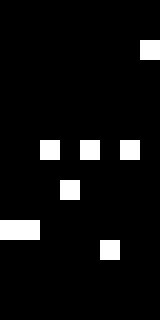

KeyboardInterrupt: 

In [32]:
from PIL import Image
from IPython.display import display
import time
from IPython.display import clear_output

for (x, y) in train_dataset:
    t = x.transpose(0, 2, 1, 3)
    arr = t[0, 3].T # numpy array of 0/1 values

    # convert to uint8 and scale 0/1 -> 0-255 if needed
    if arr.dtype != np.uint8:
        if arr.max() <= 1:
            arr = (arr.astype(np.uint8) * 255)
        else:
            arr = arr.astype(np.uint8)

    # flip vertically for human interpretability (so the origin appears at the bottom-left)
    # and ensure the array is contiguous before creating a PIL Image
    arr = np.ascontiguousarray(np.flipud(arr))
    img = Image.fromarray(arr, mode="L")

    # display much larger by resizing with nearest neighbor (preserve hard pixels)
    scale = 20  # adjust this to make it larger/smaller
    large_img = img.resize((img.width * scale, img.height * scale), resample=Image.NEAREST)

    clear_output(wait=True)   # clear previous frame to create animation effect
    display(large_img)
    time.sleep(.1)